In [2]:
import json
import gzip
import os
from experiments.problem_instance.problem_instance import ProblemInstance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
def plot(problem_instances):

    t_checkpoints = problem_instances[0].t_checkpoints
    n_checkpoints = problem_instances[0].n_checkpoints

    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(2, 2)
    #fig, axs = plt.subplots(2, 2, figsize=(16, 4))
    #ax.scatter(pi.t_checkpoints, pi.means_iid[0])

    ax = fig.add_subplot(gs[0, 0])
    ax.set_title("E[Z_nt]")
    means_iid = np.array([pi.means_iid for pi in problem_instances])
    mean_curve = means_iid.mean(axis=0)
    std_curve = means_iid.std(axis=0)
    ax.plot(t_checkpoints, mean_curve, marker="o")
    ax.fill_between(t_checkpoints, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

    vars_iid = np.array([pi.vars_iid for pi in problem_instances])
    mean_curve = vars_iid.mean(axis=0)
    ax3d = fig.add_subplot(gs[0, 1], projection="3d")
    X, Y = np.meshgrid(np.log10(n_checkpoints), np.log10(t_checkpoints))
    #ax3d.plot_wireframe(X, Y, mean_curve.T, color="steelblue")
    ax3d.plot_surface(X, Y, np.log10(mean_curve.T), cmap="Blues")
    ax3d.set_title("V[Z_nt]")
    # Set camera angle
    ax3d.view_init(elev=30, azim=45)  # elev = up/down, azim = left/right rotation

    ax3d.set_yticks(np.log10(t_checkpoints))
    ax3d.set_yticklabels(t_checkpoints)
    ax3d.set_xticks(np.log10(n_checkpoints))
    ax3d.set_xticklabels(n_checkpoints)
    ax3d.set_ylabel("t")
    ax3d.set_xlabel("n")

    ax = fig.add_subplot(gs[1, 0])
    ax.set_title("E[Z_nt|D_app]")
    means_cond = np.array([pi.means_cond for pi in problem_instances])
    mean_curve = means_cond.mean(axis=0)
    std_curve = means_cond.std(axis=0)
    ax.plot(t_checkpoints, mean_curve, marker="o")
    ax.fill_between(t_checkpoints, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

    ax = fig.add_subplot(gs[1, 1])
    ax.set_title("V[Z_nt|D_app]")
    vars_cond = np.array([pi.vars_cond for pi in problem_instances])
    mean_curve = vars_cond.mean(axis=0)
    std_curve = vars_cond.std(axis=0)
    ax.plot(t_checkpoints, mean_curve, marker="o")
    ax.fill_between(t_checkpoints, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

    axs = np.array(fig.get_axes()).reshape(2, 2)
    for i, ax in enumerate(axs.flatten()):
        if i != 1:
            ax.set_xscale("log")
            if i == 3:
                ax.set_yscale("log")
            ax.set_xlabel("$t$")

    return fig, axs

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


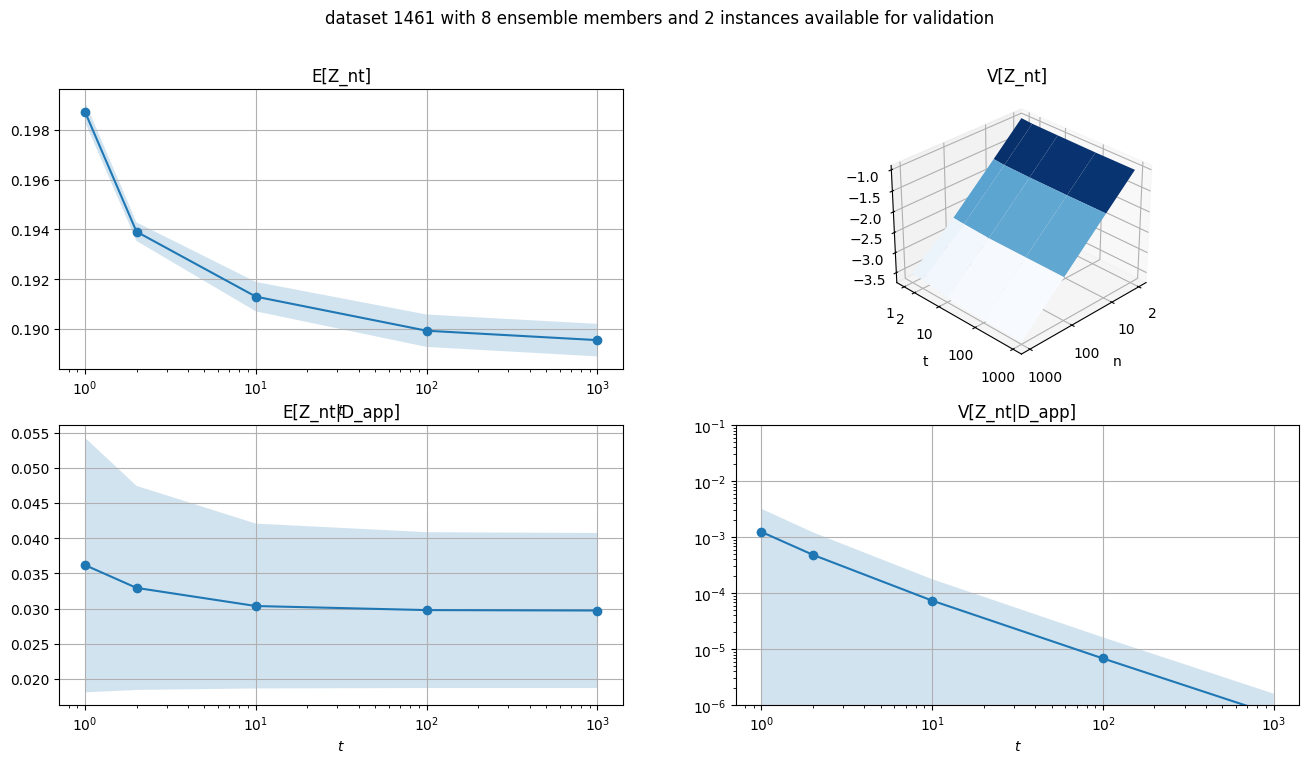

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


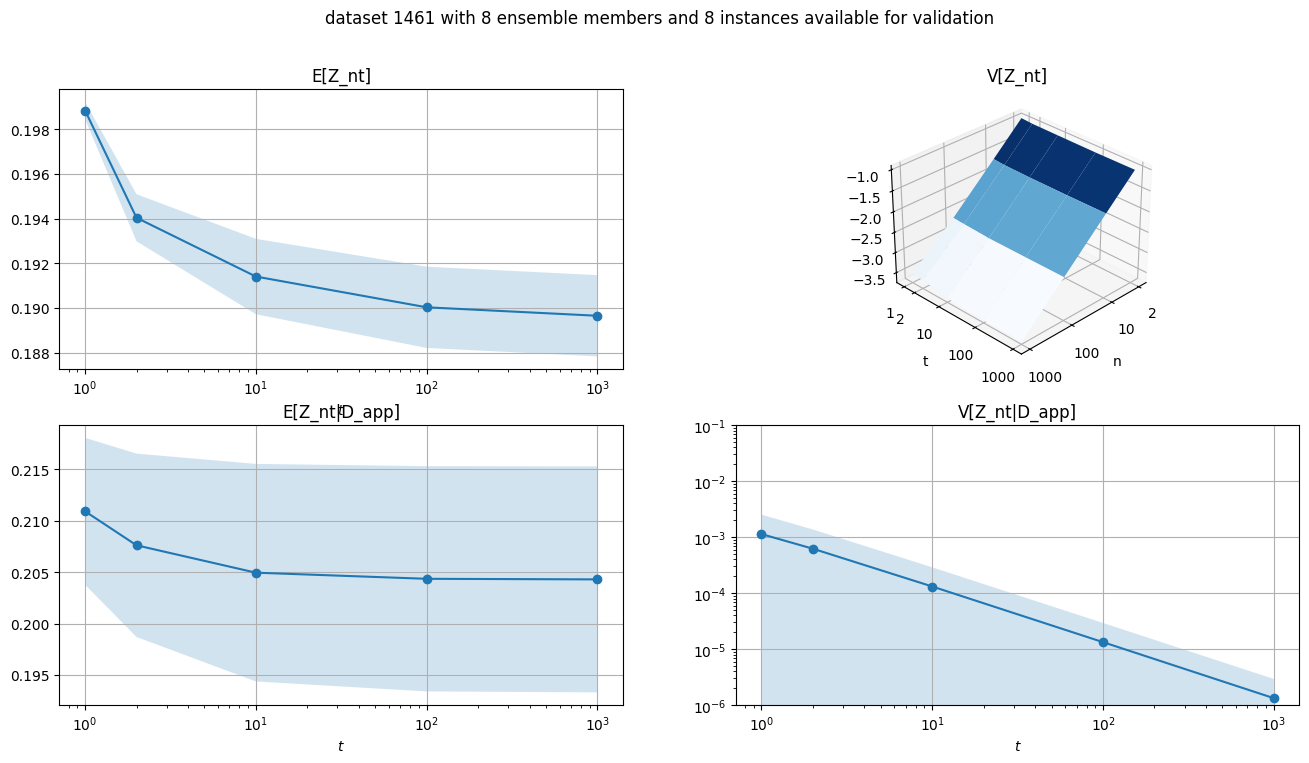

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


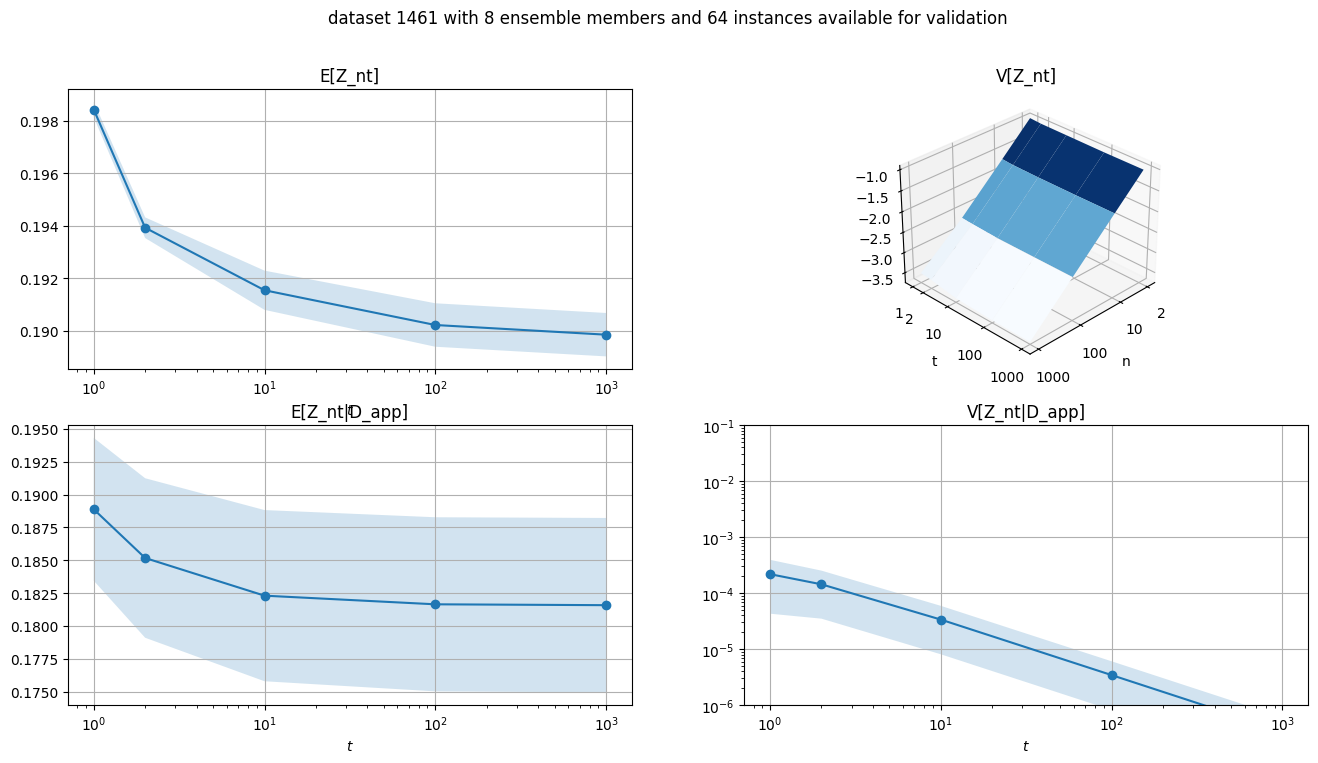

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


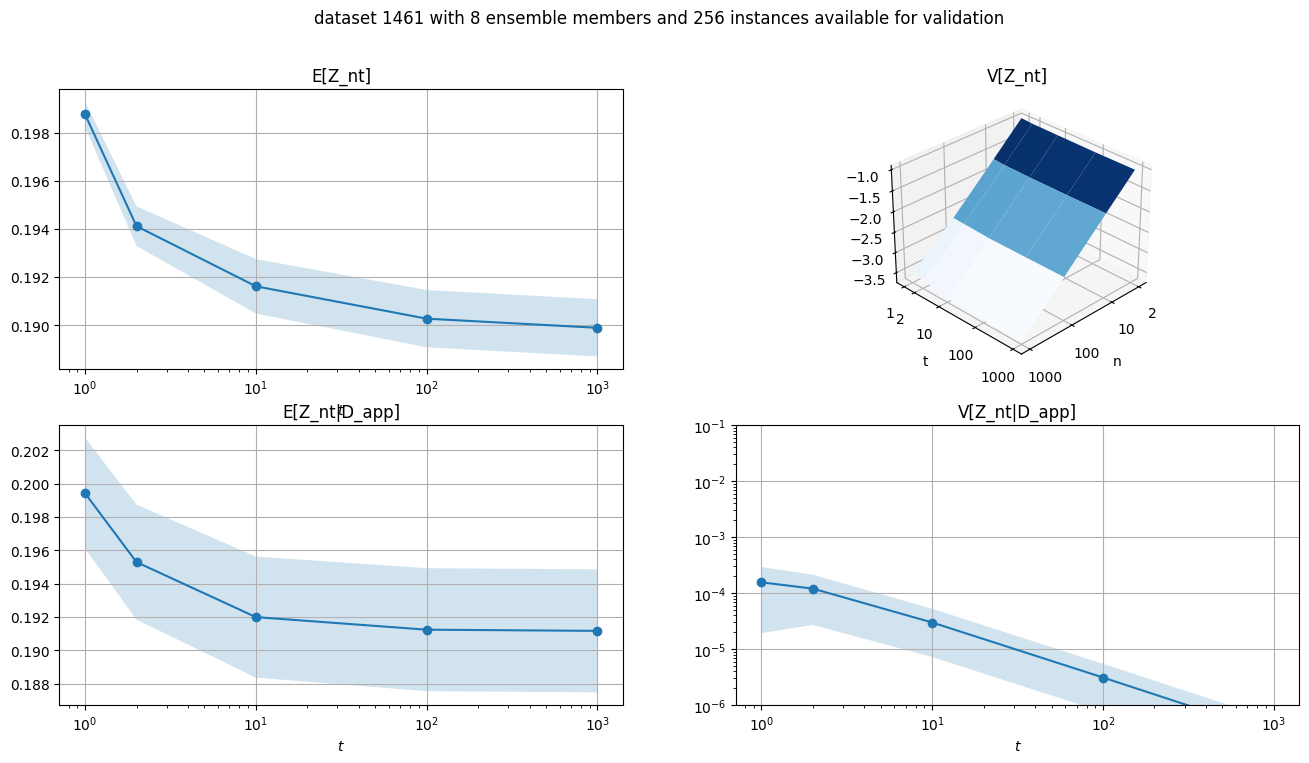

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


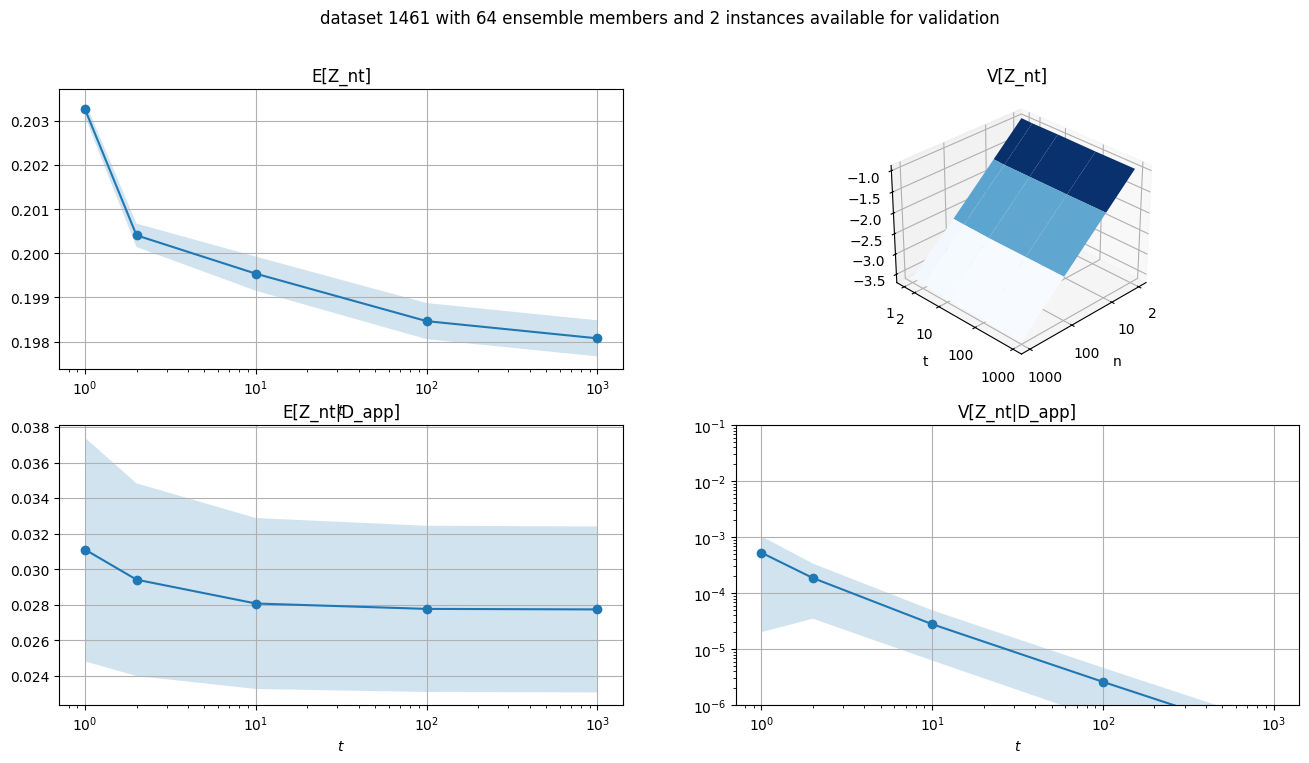

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


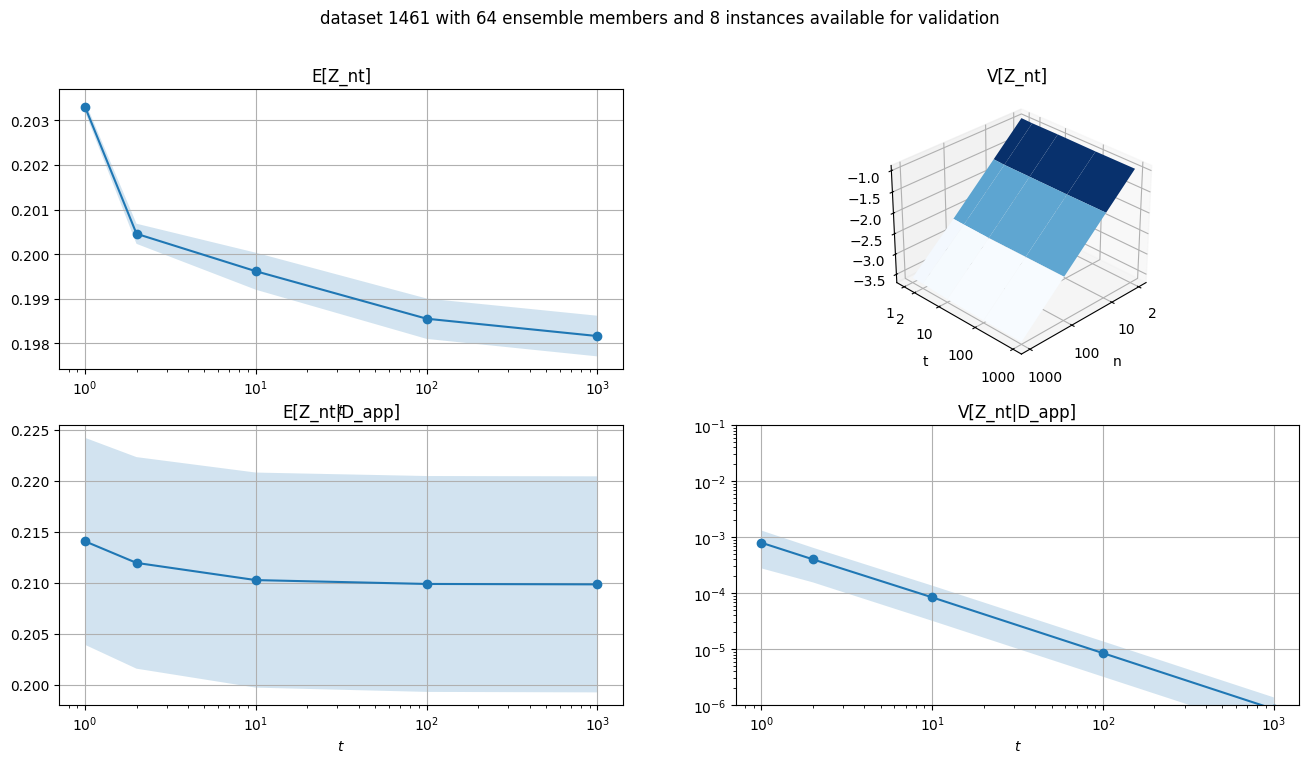

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


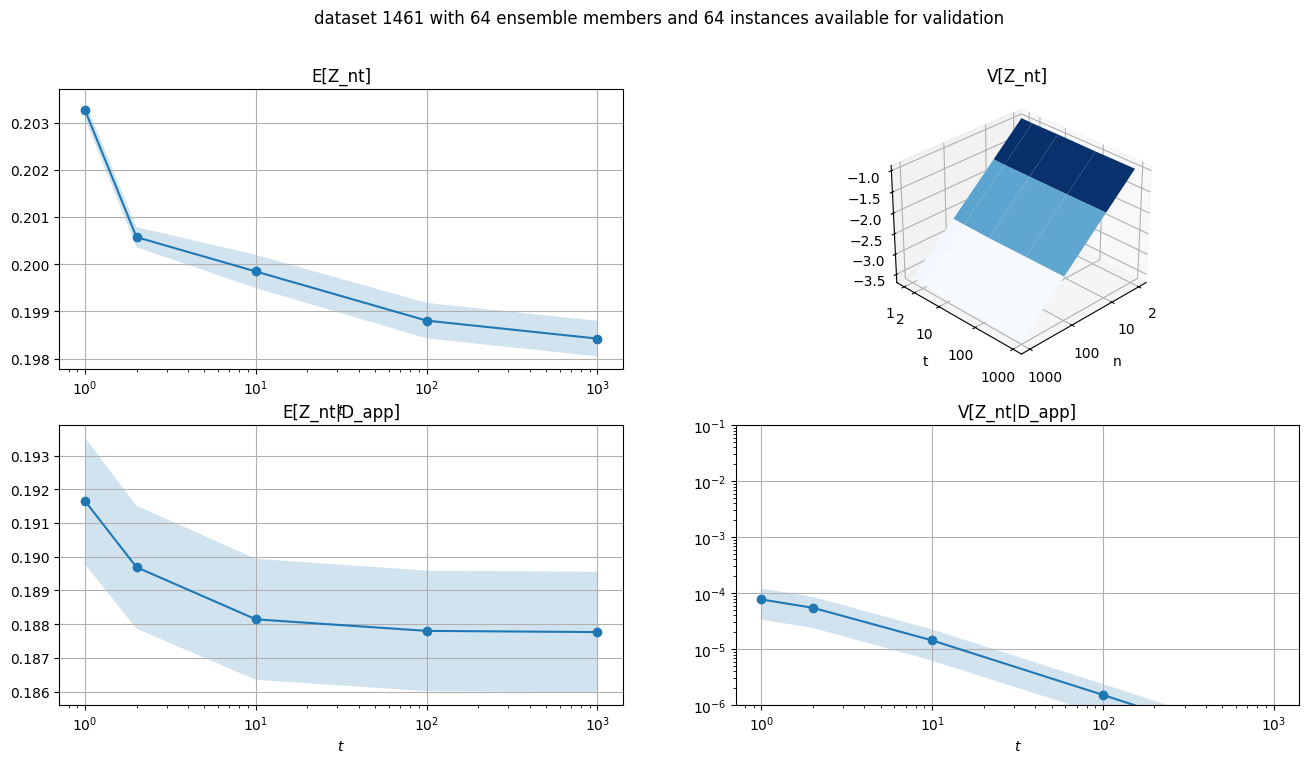

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


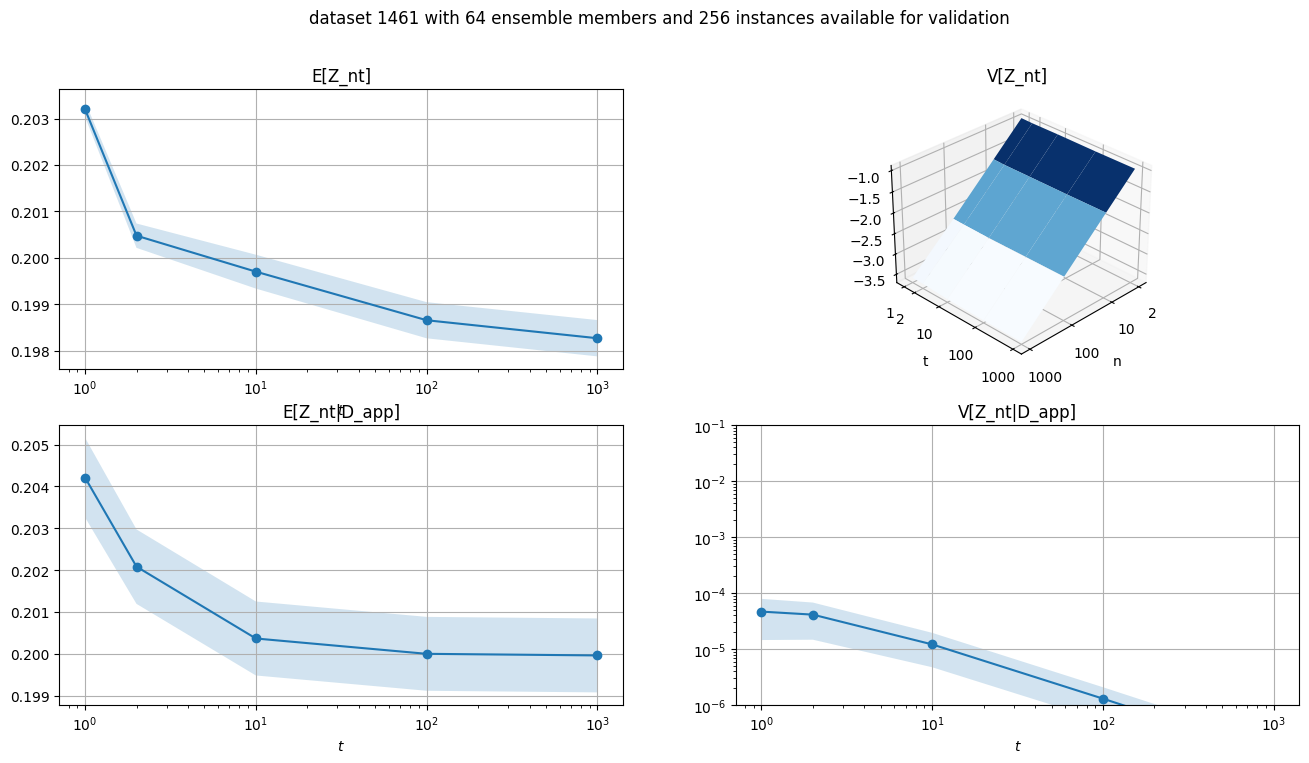

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


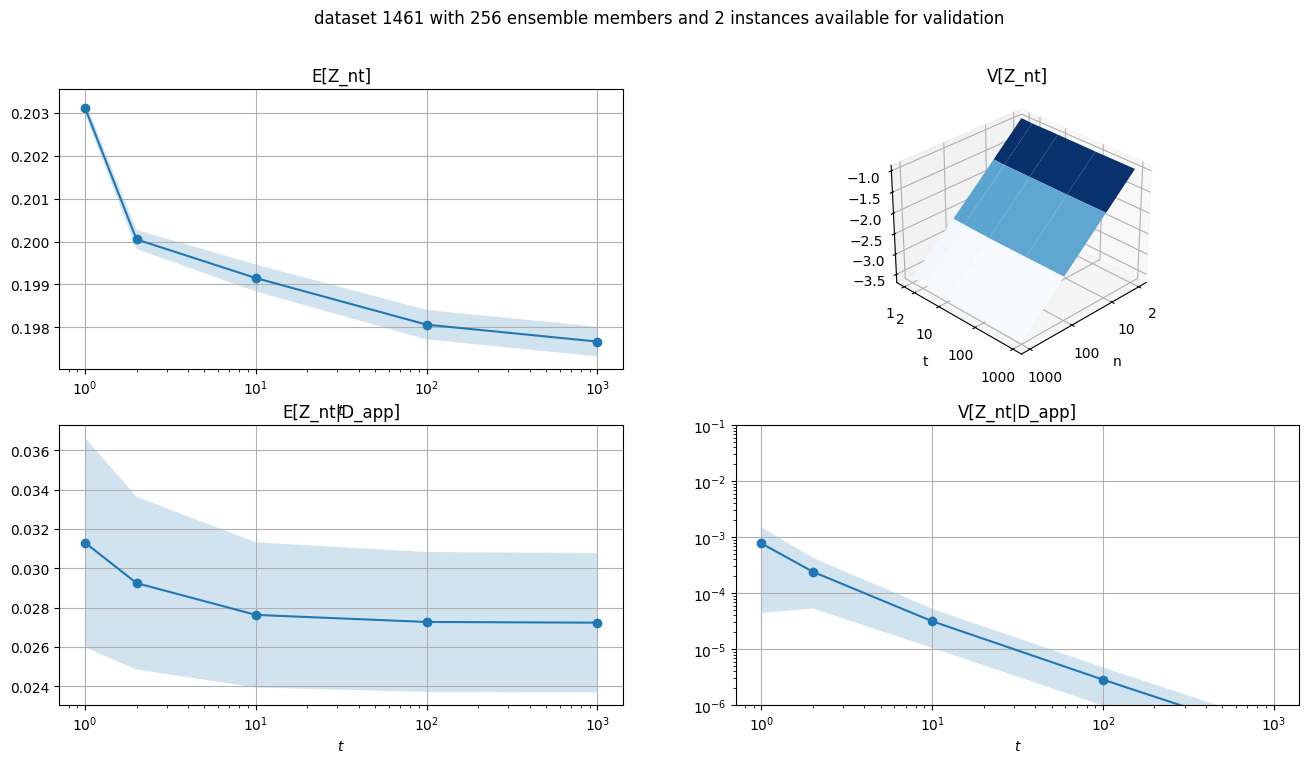

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


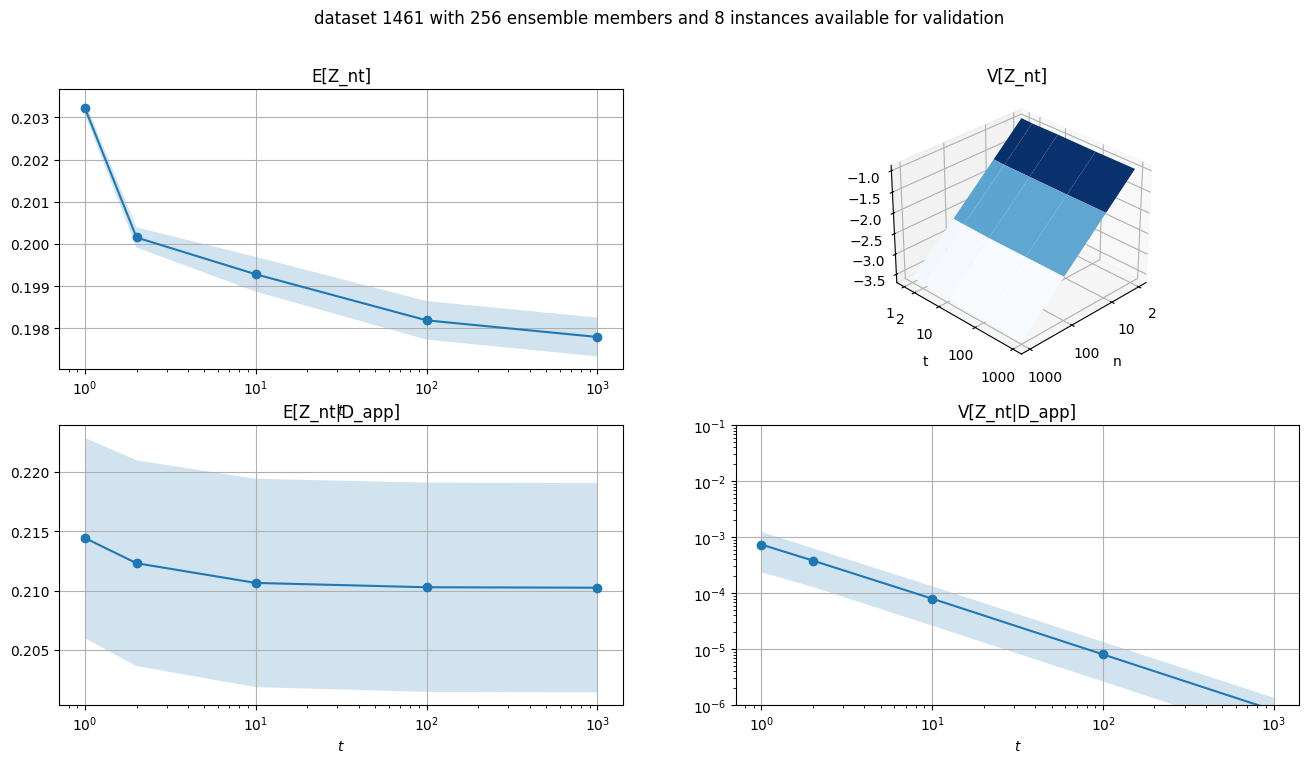

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


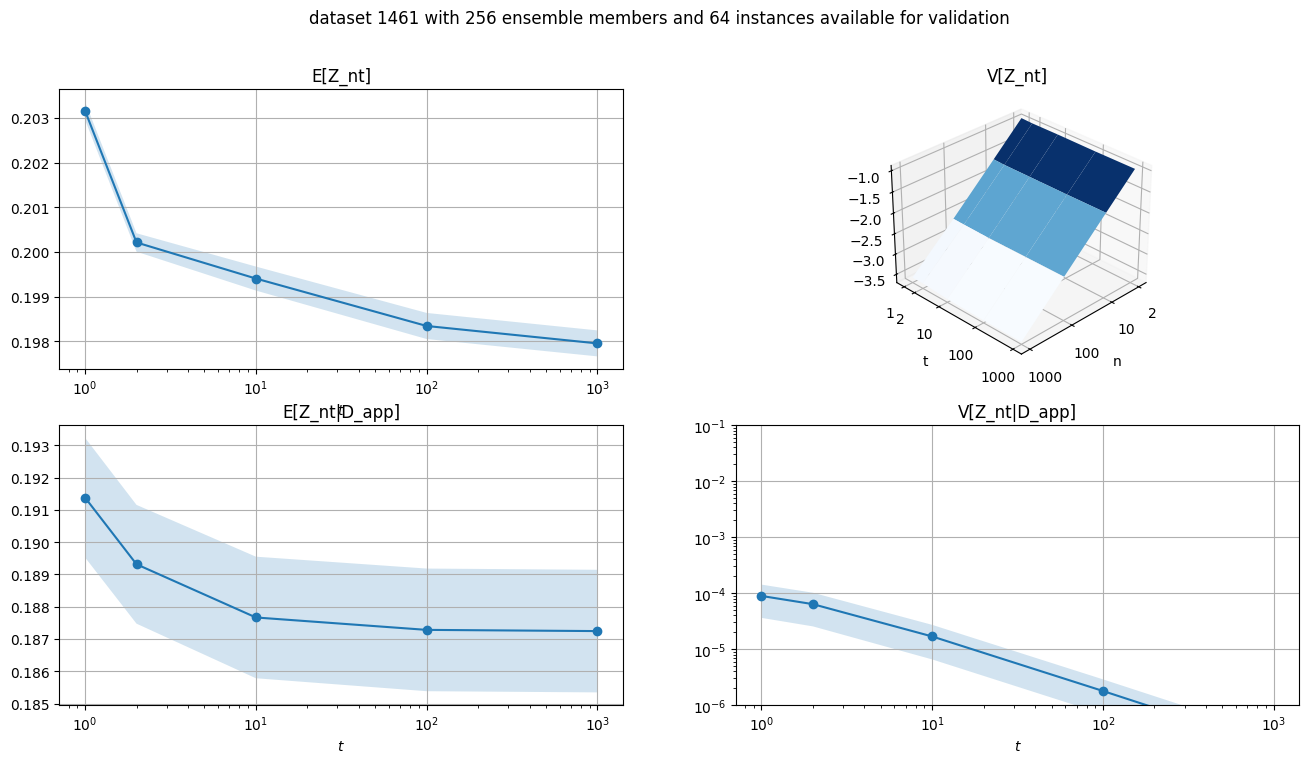

/tmp/ipykernel_177129/1159670503.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=3.0)


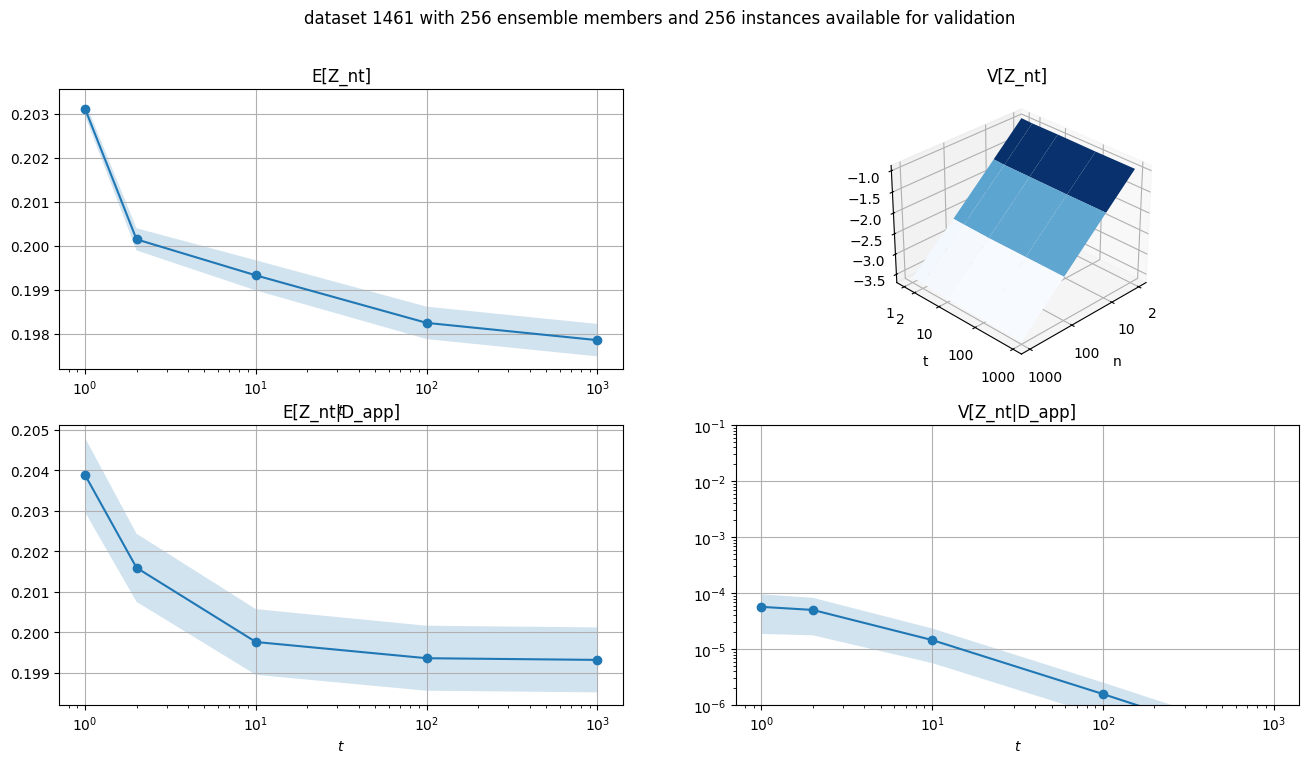

In [7]:
openmlid = 1461
for num_trees in [8, 64, 256]:
    for val_instances in [2, 8, 64, 256]:
        with open(f"merged instances/{openmlid}_{num_trees}_{val_instances}.json", "r") as f:
            problem_instances = [ProblemInstance.from_dict(d) for d in json.load(f)]

        fig, axs = plot(problem_instances)
        fig.suptitle(f"dataset {openmlid} with {num_trees} ensemble members and {val_instances} instances available for validation")
        fig.tight_layout(pad=3.0)
        axs[1, 1].set_ylim([10**-6, 10**-1])
        for i, ax in enumerate(axs.flatten()):
            if i != 1:
                ax.grid()
        plt.show()